## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2009,0.230901,0.315722,0.162619,-0.315722,0.205831,0.289935,0.158879,-0.289935,0.048579,0.050930,0.073114,0.050930,4.360424,-2.787257,0.786584,4.699393,NaN,NaN,NaN,1.761039,NaN,NaN,NaN,3.230216,NaN,NaN,NaN,13.118672,73.665845,137.085867,398.284212,406.678840,159.569182,5.147393,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840,0,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN
1,2009-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.664674,-0.116201,3.274236,6.793895,NaN,NaN,NaN,1.699212,NaN,NaN,NaN,4.246554,NaN,NaN,NaN,7.838270,45.404332,92.588013,237.966227,242.986365,61.584229,1.986588,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-4.344107,13.624337,242.986365,0,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,23291.0,94577.0,25594.0,143462.0,22117.0,93495.0,30638.0,146250.0,5066.81,NaN,NaN
2,2009-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.264925,1.897135,4.081030,6.264925,NaN,NaN,NaN,2.651805,NaN,NaN,NaN,4.458365,NaN,NaN,NaN,8.009196,48.291400,89.714789,243.559852,248.285067,45.061856,1.453608,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.0,1.0,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,6,1,2,-1.838750,13.054948,248.285067,0,16.833333,19.500000,44.318182,847.277279,42

<AxesSubplot:>

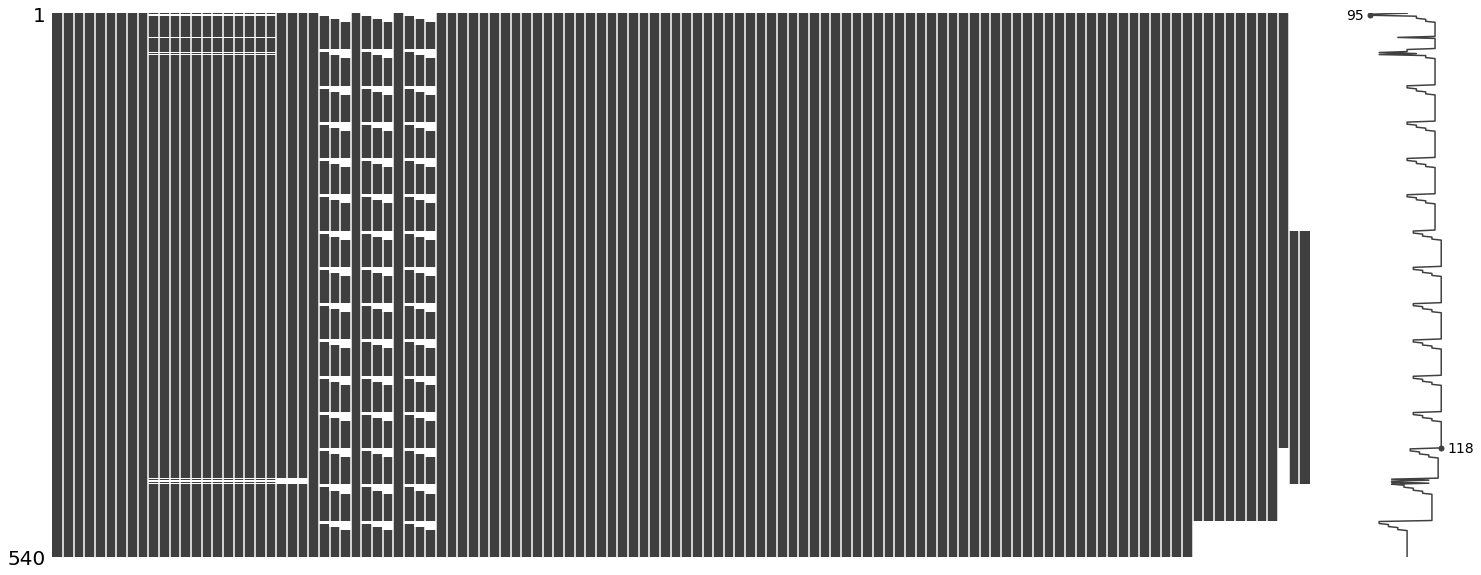

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,1.6667
1,ndmi,1.6667
2,ndwi,1.6667
3,ndbi,1.6667
4,ndvi_mean,1.6667
...,...,...
30,F_Y_GE65,6.6667
31,F_TOTAL,6.6667
32,MIO_EUR,20.0000
33,L_TOTAL,53.3333


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_NAME.unique()

In [7]:
data = []

for year in years:
    for region in nuts3_units:
        filtered_df = dataset_monthly.loc[(dataset_monthly['year'] == year) & (dataset_monthly['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        q1_df = filtered_df.loc[(filtered_df['month'] <= 3)]
        q2_df = filtered_df.loc[(filtered_df['month'] <= 6)]
        q3_df = filtered_df.loc[(filtered_df['month'] <= 9)]
        q4_df = filtered_df.loc[(filtered_df['month'] <= 12)]

        min_temp_q1 = q1_df['lst_mean'].min()
        mean_temp_q1 = q1_df['lst_mean'].mean()
        max_temp_q1 = q1_df['lst_mean'].max()
        prec_q1 = q1_df['rainfall_mean'].sum()

        ndvi_q1 = q1_df['ndvi'].mean()
        ndwi_q1 = q1_df['ndwi'].mean()
        ndmi_q1 = q1_df['ndmi'].mean()
        ndbi_q1 = q1_df['ndbi'].mean()

        ndvi_mean_q1 = q1_df['ndvi_mean'].mean()
        ndwi_mean_q1 = q1_df['ndwi_mean'].mean()
        ndmi_mean_q1 = q1_df['ndmi_mean'].mean()
        ndbi_mean_q1 = q1_df['ndbi_mean'].mean()

        ndvi_std_q1 = q1_df['ndvi_std'].mean()
        ndwi_std_q1 = q1_df['ndwi_std'].mean()
        ndmi_std_q1 = q1_df['ndmi_std'].mean()
        ndbi_std_q1 = q1_df['ndbi_std'].mean()

        min_temp_q2 = q2_df['lst_mean'].min()
        mean_temp_q2 = q2_df['lst_mean'].mean()
        max_temp_q2 = q2_df['lst_mean'].max()
        prec_q2 = q2_df['rainfall_mean'].sum()

        ndvi_q2 = q2_df['ndvi'].mean()
        ndwi_q2 = q2_df['ndwi'].mean()
        ndmi_q2 = q2_df['ndmi'].mean()
        ndbi_q2 = q2_df['ndbi'].mean()

        ndvi_mean_q2 = q2_df['ndvi_mean'].mean()
        ndwi_mean_q2 = q2_df['ndwi_mean'].mean()
        ndmi_mean_q2 = q2_df['ndmi_mean'].mean()
        ndbi_mean_q2 = q2_df['ndbi_mean'].mean()

        ndvi_std_q2 = q2_df['ndvi_std'].mean()
        ndwi_std_q2 = q2_df['ndwi_std'].mean()
        ndmi_std_q2 = q2_df['ndmi_std'].mean()
        ndbi_std_q2 = q2_df['ndbi_std'].mean()

        min_temp_q3 = q3_df['lst_mean'].min()
        mean_temp_q3 = q3_df['lst_mean'].mean()
        max_temp_q3 = q3_df['lst_mean'].max()
        prec_q3 = q3_df['rainfall_mean'].sum()

        ndvi_q3 = q3_df['ndvi'].mean()
        ndwi_q3 = q3_df['ndwi'].mean()
        ndmi_q3 = q3_df['ndmi'].mean()
        ndbi_q3 = q3_df['ndbi'].mean()

        ndvi_mean_q3 = q3_df['ndvi_mean'].mean()
        ndwi_mean_q3 = q3_df['ndwi_mean'].mean()
        ndmi_mean_q3 = q3_df['ndmi_mean'].mean()
        ndbi_mean_q3 = q3_df['ndbi_mean'].mean()

        ndvi_std_q3 = q3_df['ndvi_std'].mean()
        ndwi_std_q3 = q3_df['ndwi_std'].mean()
        ndmi_std_q3 = q3_df['ndmi_std'].mean()
        ndbi_std_q3 = q3_df['ndbi_std'].mean()

        min_temp_q4 = q4_df['lst_mean'].min()
        mean_temp_q4 = q4_df['lst_mean'].mean()
        max_temp_q4 = q4_df['lst_mean'].max()
        prec_q4 = q4_df['rainfall_mean'].sum()

        ndvi_q4 = q4_df['ndvi'].mean()
        ndwi_q4 = q4_df['ndwi'].mean()
        ndmi_q4 = q4_df['ndmi'].mean()
        ndbi_q4 = q4_df['ndbi'].mean()

        ndvi_mean_q4 = q4_df['ndvi_mean'].mean()
        ndwi_mean_q4 = q4_df['ndwi_mean'].mean()
        ndmi_mean_q4 = q4_df['ndmi_mean'].mean()
        ndbi_mean_q4 = q4_df['ndbi_mean'].mean()

        ndvi_std_q4 = q4_df['ndvi_std'].mean()
        ndwi_std_q4 = q4_df['ndwi_std'].mean()
        ndmi_std_q4 = q4_df['ndmi_std'].mean()
        ndbi_std_q4 = q4_df['ndbi_std'].mean()

        data.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'min_temp_q1': min_temp_q1,
                     'mean_temp_q1': mean_temp_q1,
                     'max_temp_q1': max_temp_q1,
                     'prec_q1': prec_q1,
                     'ndvi_q1': ndvi_q1,
                     'ndwi_q1': ndwi_q1,
                     'ndmi_q1': ndmi_q1,
                     'ndbi_q1': ndbi_q1,
                     'ndvi_mean_q1': ndvi_mean_q1,
                     'ndwi_mean_q1': ndwi_mean_q1,
                     'ndmi_mean_q1': ndmi_mean_q1,
                     'ndbi_mean_q1': ndbi_mean_q1,
                     'ndvi_std_q1': ndvi_std_q1,
                     'ndwi_std_q1': ndwi_std_q1,
                     'ndmi_std_q1': ndmi_std_q1,
                     'ndbi_std_q1': ndbi_std_q1,
                     'min_temp_q2': min_temp_q2,
                     'mean_temp_q2': mean_temp_q2,
                     'max_temp_q2': max_temp_q2,
                     'prec_q2': prec_q2,
                     'ndvi_q2': ndvi_q2,
                     'ndwi_q2': ndwi_q2,
                     'ndmi_q2': ndmi_q2,
                     'ndbi_q2': ndbi_q2,
                     'ndvi_mean_q2': ndvi_mean_q2,
                     'ndwi_mean_q2': ndwi_mean_q2,
                     'ndmi_mean_q2': ndmi_mean_q2,
                     'ndbi_mean_q2': ndbi_mean_q2,
                     'ndvi_std_q2': ndvi_std_q2,
                     'ndwi_std_q2': ndwi_std_q2,
                     'ndmi_std_q2': ndmi_std_q2,
                     'ndbi_std_q2': ndbi_std_q2,
                     'min_temp_q3': min_temp_q3,
                     'mean_temp_q3': mean_temp_q3,
                     'max_temp_q3': max_temp_q3,
                     'prec_q3': prec_q3,
                     'ndvi_q3': ndvi_q3,
                     'ndwi_q3': ndwi_q3,
                     'ndmi_q3': ndmi_q3,
                     'ndbi_q3': ndbi_q3,
                     'ndvi_mean_q3': ndvi_mean_q3,
                     'ndwi_mean_q3': ndwi_mean_q3,
                     'ndmi_mean_q3': ndmi_mean_q3,
                     'ndbi_mean_q3': ndbi_mean_q3,
                     'ndvi_std_q3': ndvi_std_q3,
                     'ndwi_std_q3': ndwi_std_q3,
                     'ndmi_std_q3': ndmi_std_q3,
                     'ndbi_std_q3': ndbi_std_q3,
                     'min_temp_q4': min_temp_q4,
                     'mean_temp_q4': mean_temp_q4,
                     'max_temp_q4': max_temp_q4,
                     'prec_q4': prec_q4,
                     'ndvi_q4': ndvi_q4,
                     'ndwi_q4': ndwi_q4,
                     'ndmi_q4': ndmi_q4,
                     'ndbi_q4': ndbi_q4,
                     'ndvi_mean_q4': ndvi_mean_q4,
                     'ndwi_mean_q4': ndwi_mean_q4,
                     'ndmi_mean_q4': ndmi_mean_q4,
                     'ndbi_mean_q4': ndbi_mean_q4,
                     'ndvi_std_q4': ndvi_std_q4,
                     'ndwi_std_q4': ndwi_std_q4,
                     'ndmi_std_q4': ndmi_std_q4,
                     'ndbi_std_q4': ndbi_std_q4})
        
q_df = pd.DataFrame(data)        

In [8]:
q_df

,NUTS3_NAME,year,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,"καρδιτσα, τρικαλα",2009,0.786584,4.015802,7.386993,25.625436,0.239855,0.158933,0.337128,-0.337128,0.226718,0.150033,0.317251,-0.317251,0.042921,0.064685,0.048453,0.048453,0.786584,11.539060,24.121826,34.559944,0.344602,-0.038521,0.263370,-0.263370,0.337341,-0.042501,0.252613,-0.252613,0.047999,0.055027,0.051567,0.051567,0.786584,15.838558,26.266164,40.059607,0.375395,-0.107911,0.231804,-0.231804,0.367591,-0.107835,0.223814,-0.223814,0.052132,0.052099,0.056021,0.056021,0.786584,14.568123,26.266164,67.484036,0.378780,-0.141987,0.198977,-0.198977,0.373795,-0.141283,0.193909,-0.193909,0.055709,0.059335,0.059938,0.059938
1,λαρισα,2009,3.274236,6.096099,9.243013,15.157873,0.399270,-0.216415,0.135004,-0.135004,0.390158,-0.202145,0.136768,-0.136768,0.048139,0.053193,0.054736,0.054736,3.274236,13.459017,26.705080,21.922657,0.406754,-0.247310,0.133016,-0.133016,0.400103,-0.240348,0.132426,-0.132426,0.050920,0.043575,0.056778,0.056778,3.274236,17.892070,28.610900,27.626142,0.374954,-0.269620,0.088810,-0.088810,0.370915,-0.262433,0.091322,-0.091322,0.054899,0.042649,0.062524,0.062524,3.274236,16.526279,28.610900,47.527724,0.345333,-0.281079,0.049365,-0.049365,0.339808,-0.274709,0.050335,-0.050335,0.055668,0.041242,0.060761,0.060761
2,"μαγνησια, σποραδες",2009,4.081030,6.386193,9.381740,15.624342,0.389420,-0.138705,0.194908,-0.194908,0.389192,-0.141481,0.193118,-0.193118,0.043031,0.059318,0.043042,0.043042,4.081030,13.220869,25.613570,21.161977,0.417746,-0.203897,0.179001,-0.179001,0.414525,-0.202002,0.178051,-0.178051,0.044407,0.044461,0.044339,0.044339,4.081030,17.263476,27.484423,27.397194,0.404597,-0.225953,0.152687,-0.152687,0.401251,-0.223181,0.151966,-0.151966,0.048695,0.046639,0.050835,0.050835,4.081030,16.155522,27.484423,46.932585,0.399483,-0.219504,0.147640,-0.147640,0.396182,-0.215398,0.148367,-0.148367,0.049289,0.050320,0.051900,0.051900
3,"καρδιτσα, τρικαλα",2010,4.033540,6.373924,10.438221,22.922113,0.350647,-0.096530,0.213096,-0.213096,0.347643,-0.093180,0.212255,-0.212255,0.073372,0.106633,0.080937,0.080937,4.033540,12.729799,22.881211,32.019505,0.426922,-0.210829,0.189674,-0.189674,0.424283,-0.204954,0.191558,-0.191558,0.064737,0.067763,0.067757,0.067757,4.033540,16.710056,27.634238,41.006728,0.453053,-0.253862,0.176848,-0.176848,0.450133,-0.247587,0.178646,-0.178646,0.062992,0.057799,0.065701,0.065701,4.033540,14.997080,27.634238,67.017598,0.427661,-0.210489,0.186858,-0.186858,0.423715,-0.205533,0.186723,-0.186723,0.060100,0.060607,0.063089,0.063089
4,λαρισα,2010,6.060683,8.182723,11.605803,14.231084,0.320112,-0.062955,0.206351,-0.206351,0.314653,-0.053091,0.213961,-0.213961,0.049115,0.061896,0.058400,0.058400,6.060683,14.423825,25.069446,22.002000,0.380351,-0.191130,0.162495,-0.162495,0.374792,-0.183640,0.166214,-0.166214,0.055400,0.049404,0.063339,0.063339,6.060683,18.660169,29.893763,30.753594,0.388973,-0.237037,0.133235,-0.133235,0.382334,-0.229229,0.135796,-0.135796,0.054926,0.044492,0.061006,0.061006,6.015728,16.792182,29.893763,45.456191,0.370434,-0.218093,0.129705,-0.129705,0.362921,-0.208678,0.132753,-0.132753,0.054348,0.045435,0.059608,0.059608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...

In [9]:
dataset_monthly = pd.merge(dataset_monthly, q_df,  how='left', on=['NUTS3_NAME', 'year'])

In [10]:
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2009,0.230901,0.315722,0.162619,-0.315722,0.205831,0.289935,0.158879,-0.289935,0.048579,0.050930,0.073114,0.050930,4.360424,-2.787257,0.786584,4.699393,NaN,NaN,NaN,1.761039,NaN,NaN,NaN,3.230216,NaN,NaN,NaN,13.118672,73.665845,137.085867,398.284212,406.678840,159.569182,5.147393,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-12.405294,11.129308,406.678840,0,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN,0.786584,4.015802,7.386993,25.625436,0.239855,0.158933,0.337128,-0.337128,0.226718,0.150033,0.317251,-0.317251,0.042921,0.064685,0.048453,0.048453,0.786584,11.539060,24.121826,34.559944,0.344602,-0.038521,0.263370,-0.263370,0.337341,-0.042501,0.252613,-0.252613,0.047999,0.055027,0.051567,0.051567,0.786584,15.838558,26.266164,40.059607,0.375395,-0.107911,0.231804,-0.231804,0.367591,-0.107835,0.223814,-0.223814,0.052132,0.052099,0.056021,0.056021,0.786584,14.568123,26.266164,67.484036,0.378780,-0.141987,0.198977,-0.198977,0.373795,-0.141283,0.193909,-0.193909,0.055709,0.059335,0.059938,0.059938
1,2009-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.664674,-0.116201,3.274236,6.793895,NaN,NaN,NaN,1.699212,NaN,NaN,NaN,4.246554,NaN,NaN,NaN,7.838270,45.404332,92.588013,237.966227,242.986365,61.584229,

In [11]:
grouped_annualy = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual = grouped_annualy.mean()
dataset_annual.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,6.5,0.378780,0.198977,-0.141987,-0.198977,0.373795,0.193909,-0.141283,-0.193909,0.055709,0.059938,0.059335,0.059938,20.024060,9.112185,14.568123,4.699393,7.541364,13.255044,13.971789,1.761039,0.200398,1.498356,2.100476,3.230216,3.870881,7.395288,8.052656,5.623670,31.352104,66.179708,170.329448,1115.959740,403.428459,13.217011,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0.0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48.0,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,5.140508,25.476976,171.579082,0.00,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN,0.786584,4.015802,7.386993,25.625436,0.239855,0.158933,0.337128,-0.337128,0.226718,0.150033,0.317251,-0.317251,0.042921,0.064685,0.048453,0.048453,0.786584,11.539060,24.121826,34.559944,0.344602,-0.038521,0.263370,-0.263370,0.337341,-0.042501,0.252613,-0.252613,0.047999,0.055027,0.051567,0.051567,0.786584,15.838558,26.266164,40.059607,0.375395,-0.107911,0.231804,-0.231804,0.367591,-0.107835,0.223814,-0.223814,0.052132,0.052099,0.056021,0.056021,0.786584,14.568123,26.266164,67.484036,0.378780,-0.141987,0.198977,-0.198977,0.373795,-0.141283,0.193909,-0.193909,0.055709,0.059335,0.059938,0.059938
1,2009,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,6.5,0.345333,0.049365,-0.281079,-0.049365,0.339808,0.050335,-0.274709,-0.050335,0.055668,0.060761,0.041242,0.060761,23.246765,9.805792,16.526279,6.793895,10

In [12]:
grouped_annualy_cases = dataset_monthly.groupby(['year', 'NUTS2_ID',	'NUTS2_NAME',	'NUTS3_ID',	'NUTS3_NAME'], as_index = False)
dataset_annual_cases = grouped_annualy_cases.sum()
dataset_annual_cases.head()

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",260.646462,474.086949,78,4.166582,2.188751,-1.561861,-2.188751,4.111746,2.132995,-1.554113,-2.132995,0.612794,0.659322,0.652686,0.659322,240.288726,109.346219,174.817472,56.392710,82.955000,132.550436,125.746099,21.132468,2.204373,14.983560,18.904286,38.762589,42.579687,73.952882,72.473900,67.484036,376.225242,794.156494,2043.953370,13391.516881,4841.141509,158.604126,326405.667645,15292.281665,172.641509,1885.349228,7111.282595,2117.360911,0.119653,2316.235452,0.000000,128.858826,0,0.000000,1026.902892,1337.108860,0.0,12.0,582398.212449,45134.705555,576,3620.018115,20748.830243,2701.211665,31.013601,209587.390746,140936.111162,10148.357104,140.110604,655.753009,5750.072038,197.572254,1.767524,17119.533513,372,432,360,144,144,12,72,84,24,61.686102,305.723711,2058.948979,0,179.5,241.0,454.716981,11008.467815,492.0,-144.0,636.0,68.0,302.0,310.0,46.0,24624.0,4872.0,540.0,833.225193,11652.0,1992.0,2400.0,10068.0,209592.0,927216.0,336996.0,1473804.0,205260.0,894636.0,425028.0,1524924.0,39554.16,0.0,0.0,9.439003,48.189629,88.643916,307.505228,2.878255,1.907195,4.045536,-4.045536,2.720611,1.800400,3.807008,-3.807008,0.515053,0.776226,0.581441,0.581441,9.439003,138.468719,289.461912,414.719326,4.135227,-0.462255,3.160440,-3.160440,4.048095,-0.510006,3.031359,-3.031359,0.575987,0.660326,0.618801,0.618801,9.439003,190.062690,315.193962,480.715283,4.504745,-1.294937,2.781654,-2.781654,4.411089,-1.294015,2.685764,-2.685764,0.625583,0.625194,0.672253,0.672253,9.439003,174.817472,315.193962,809.808432,4.545362,-1.703848,2.387728,-2.387728,4.485541,-1.695396,2.326904,-2.326904,0.668503,0.712021,0.719260,0.719260
1,2009,EL61,θεσσαλια,EL612,λαρισα,268.890884,476.424525,78,3.798659,0.543012,-3.091868,-0.543012,3.737883,0.553684,-3.021797,-0.553684,0.612344,0.668375,0.4536

In [13]:
dataset_annual.drop(columns=['month'], inplace=True)
print(dataset_annual.shape)

(45, 180)


In [14]:
dataset_annual['cases'] = dataset_annual_cases['cases']
dataset_annual['mosq_pred_mean'] = dataset_annual_cases['mosq_pred_mean']

<AxesSubplot:>

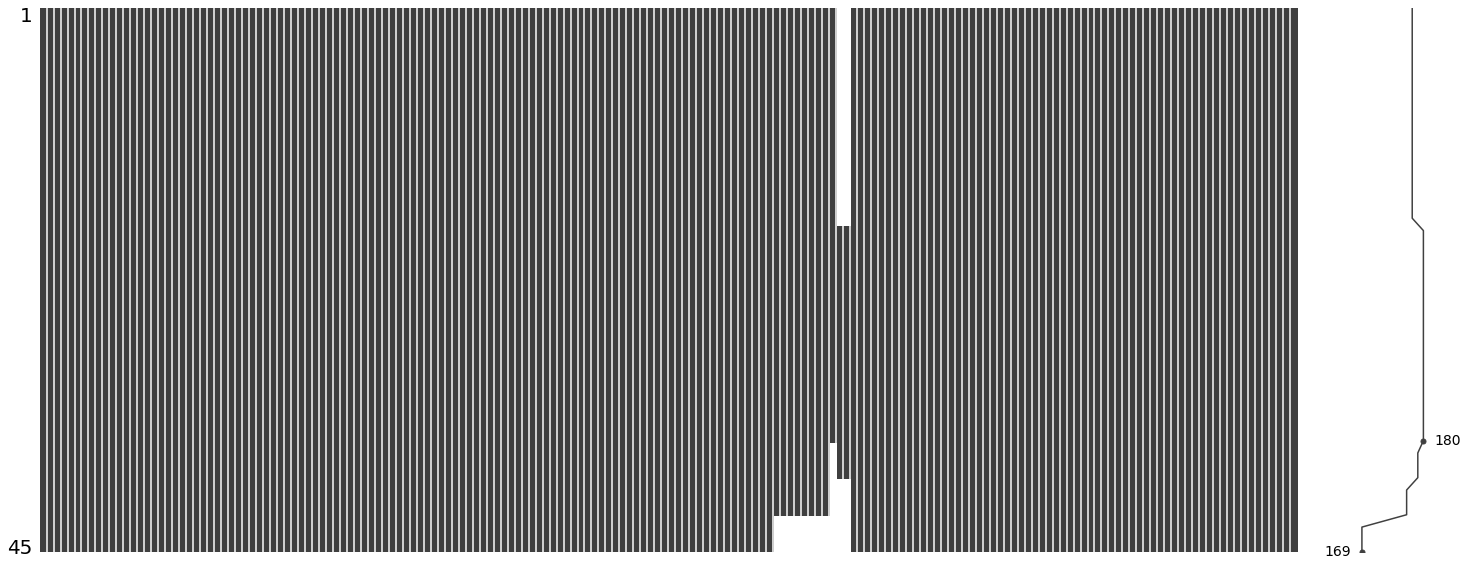

In [15]:
missingno.matrix(dataset_annual)

In [16]:
missing = describe_dataframe(dataset_annual, remove_zeros=True)
missing

,Column,Missing
0,M_Y_LT15,6.6667
1,M_Y15-64,6.6667
2,M_Y_GE65,6.6667
3,M_TOTAL,6.6667
4,F_Y_LT15,6.6667
5,F_Y15-64,6.6667
6,F_Y_GE65,6.6667
7,F_TOTAL,6.6667
8,MIO_EUR,20.0000
9,L_TOTAL,53.3333


In [17]:
dataset_annual.head(15)

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2009,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,0.378780,0.198977,-0.141987,-0.198977,0.373795,0.193909,-0.141283,-0.193909,0.055709,0.059938,0.059335,0.059938,20.024060,9.112185,14.568123,4.699393,7.541364,13.255044,13.971789,1.761039,0.200398,1.498356,2.100476,3.230216,3.870881,7.395288,8.052656,5.623670,31.352104,66.179708,170.329448,1115.959740,403.428459,158.604126,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0.0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48.0,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,5.140508,25.476976,171.579082,0,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,NaN,NaN,0.786584,4.015802,7.386993,25.625436,0.239855,0.158933,0.337128,-0.337128,0.226718,0.150033,0.317251,-0.317251,0.042921,0.064685,0.048453,0.048453,0.786584,11.539060,24.121826,34.559944,0.344602,-0.038521,0.263370,-0.263370,0.337341,-0.042501,0.252613,-0.252613,0.047999,0.055027,0.051567,0.051567,0.786584,15.838558,26.266164,40.059607,0.375395,-0.107911,0.231804,-0.231804,0.367591,-0.107835,0.223814,-0.223814,0.052132,0.052099,0.056021,0.056021,0.786584,14.568123,26.266164,67.484036,0.378780,-0.141987,0.198977,-0.198977,0.373795,-0.141283,0.193909,-0.193909,0.055709,0.059335,0.059938,0.059938
1,2009,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,0.345333,0.049365,-0.281079,-0.049365,0.339808,0.050335,-0.274709,-0.050335,0.055668,0.060761,0.041242,0.060761,23.246765,9.805792,16.526279,6.793895,10.575814,16.24216

In [18]:
dataset_annual.cases.sum()

210

In [19]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [20]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [21]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

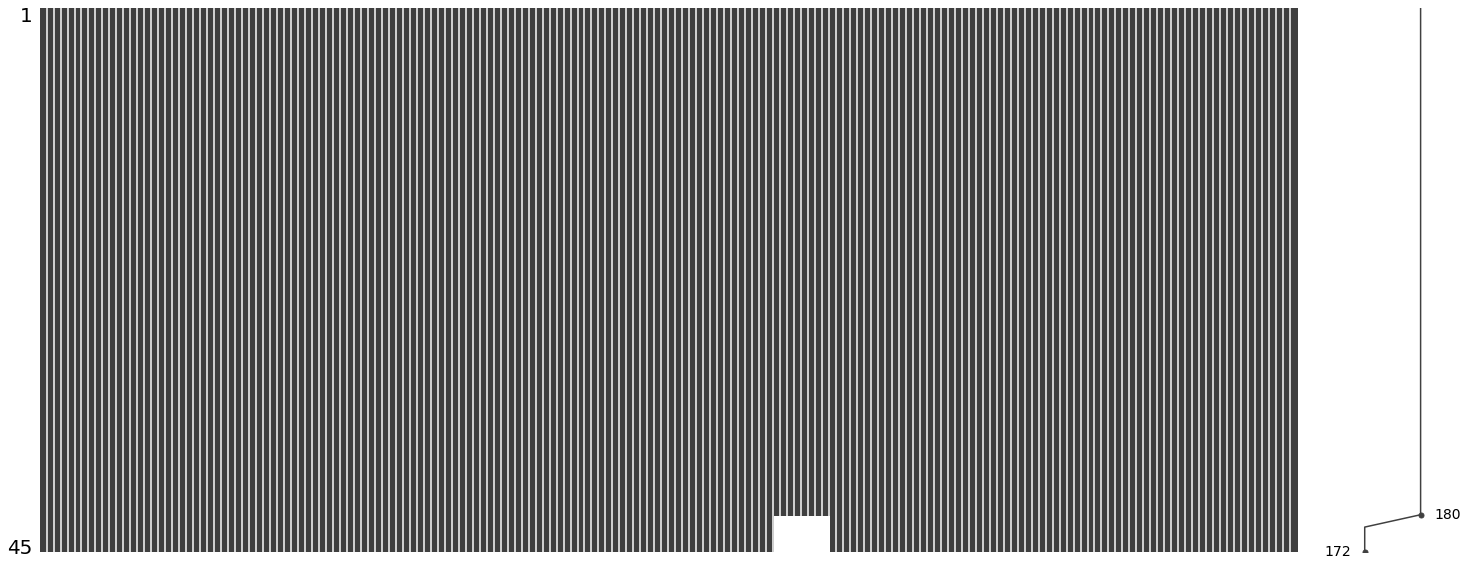

In [22]:
missingno.matrix(dataset_annual, label_rotation=90)

<AxesSubplot:>

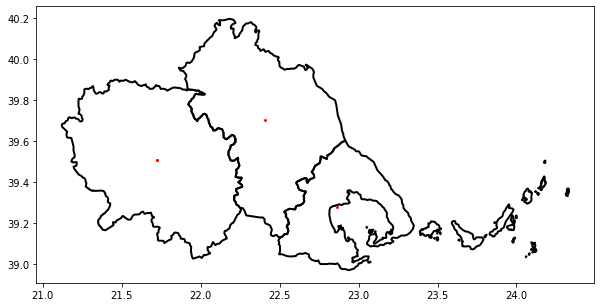

In [23]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(dataset_annual[['NUTS3_NAME']], geometry=gpd.points_from_xy(dataset_annual.x, dataset_annual.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [24]:
data_q1 = []
data_q2 = []
data_q3 = []
data_q4 = []

for year in years[1:]:
    for region in nuts3_units:

        df_preceding = dataset_annual.loc[(dataset_annual['year'] == year-1) & (dataset_annual['NUTS3_NAME'] == region)]
        df_current = dataset_annual.loc[(dataset_annual['year'] == year) & (dataset_annual['NUTS3_NAME'] == region)]

        data_q1.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q1': df_current.min_temp_q1.iloc[0],
                        'mean_temp_q1': df_current.mean_temp_q1.iloc[0],
                        'max_temp_q1': df_current.max_temp_q1.iloc[0],
                        'prec_q1': df_current.prec_q1.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q1': df_current.ndvi_q1.iloc[0],
                        'ndwi_q1': df_current.ndwi_q1.iloc[0],
                        'ndmi_q1': df_current.ndmi_q1.iloc[0],
                        'ndbi_q1': df_current.ndbi_q1.iloc[0],
                        'ndvi_mean_q1': df_current.ndvi_mean_q1.iloc[0],
                        'ndwi_mean_q1': df_current.ndwi_mean_q1.iloc[0],
                        'ndmi_mean_q1': df_current.ndmi_mean_q1.iloc[0],
                        'ndbi_mean_q1': df_current.ndbi_mean_q1.iloc[0],
                        'ndvi_std_q1': df_current.ndvi_std_q1.iloc[0],
                        'ndwi_std_q1': df_current.ndwi_std_q1.iloc[0],
                        'ndmi_std_q1': df_current.ndmi_std_q1.iloc[0],
                        'ndbi_std_q1': df_current.ndbi_std_q1.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q2.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q2': df_current.min_temp_q2.iloc[0],
                        'mean_temp_q2': df_current.mean_temp_q2.iloc[0],
                        'max_temp_q2': df_current.max_temp_q2.iloc[0],
                        'prec_q2': df_current.prec_q2.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q2': df_current.ndvi_q2.iloc[0],
                        'ndwi_q2': df_current.ndwi_q2.iloc[0],
                        'ndmi_q2': df_current.ndmi_q2.iloc[0],
                        'ndbi_q2': df_current.ndbi_q2.iloc[0],
                        'ndvi_mean_q2': df_current.ndvi_mean_q2.iloc[0],
                        'ndwi_mean_q2': df_current.ndwi_mean_q2.iloc[0],
                        'ndmi_mean_q2': df_current.ndmi_mean_q2.iloc[0],
                        'ndbi_mean_q2': df_current.ndbi_mean_q2.iloc[0],
                        'ndvi_std_q2': df_current.ndvi_std_q2.iloc[0],
                        'ndwi_std_q2': df_current.ndwi_std_q2.iloc[0],
                        'ndmi_std_q2': df_current.ndmi_std_q2.iloc[0],
                        'ndbi_std_q2': df_current.ndbi_std_q2.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q3.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q3': df_current.min_temp_q3.iloc[0],
                        'mean_temp_q3': df_current.mean_temp_q3.iloc[0],
                        'max_temp_q3': df_current.max_temp_q3.iloc[0],
                        'prec_q3': df_current.prec_q3.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q3': df_current.ndvi_q3.iloc[0],
                        'ndwi_q3': df_current.ndwi_q3.iloc[0],
                        'ndmi_q3': df_current.ndmi_q3.iloc[0],
                        'ndbi_q3': df_current.ndbi_q3.iloc[0],
                        'ndvi_mean_q3': df_current.ndvi_mean_q3.iloc[0],
                        'ndwi_mean_q3': df_current.ndwi_mean_q3.iloc[0],
                        'ndmi_mean_q3': df_current.ndmi_mean_q3.iloc[0],
                        'ndbi_mean_q3': df_current.ndbi_mean_q3.iloc[0],
                        'ndvi_std_q3': df_current.ndvi_std_q3.iloc[0],
                        'ndwi_std_q3': df_current.ndwi_std_q3.iloc[0],
                        'ndmi_std_q3': df_current.ndmi_std_q3.iloc[0],
                        'ndbi_std_q3': df_current.ndbi_std_q3.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q4.append({'year': year, 
                        'NUTS2_ID':df_current.NUTS2_ID.iloc[0],
                        'NUTS2_NAME': df_current.NUTS2_NAME.iloc[0],
                        'NUTS3_ID':df_current.NUTS3_ID.iloc[0],
                        'NUTS3_NAME': region,
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q4': df_current.min_temp_q4.iloc[0],
                        'mean_temp_q4': df_current.mean_temp_q4.iloc[0],
                        'max_temp_q4': df_current.max_temp_q4.iloc[0],
                        'prec_q4': df_current.prec_q4.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q4': df_current.ndvi_q4.iloc[0],
                        'ndwi_q4': df_current.ndwi_q4.iloc[0],
                        'ndmi_q4': df_current.ndmi_q4.iloc[0],
                        'ndbi_q4': df_current.ndbi_q4.iloc[0],
                        'ndvi_mean_q4': df_current.ndvi_mean_q4.iloc[0],
                        'ndwi_mean_q4': df_current.ndwi_mean_q4.iloc[0],
                        'ndmi_mean_q4': df_current.ndmi_mean_q4.iloc[0],
                        'ndbi_mean_q4': df_current.ndbi_mean_q4.iloc[0],
                        'ndvi_std_q4': df_current.ndvi_std_q4.iloc[0],
                        'ndwi_std_q4': df_current.ndwi_std_q4.iloc[0],
                        'ndmi_std_q4': df_current.ndmi_std_q4.iloc[0],
                        'ndbi_std_q4': df_current.ndbi_std_q4.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'distance_to_coast': df_preceding.distance_to_coast.iloc[0],
                        'distance_to_river': df_preceding.distance_to_river.iloc[0],
                        'slope_mean_1km': df_preceding.slope_mean_1km.iloc[0],
                        'aspect_mean_200m': df_preceding.aspect_mean_200m.iloc[0],
                        'elevation_mean_1km': df_preceding.elevation_mean_1km.iloc[0],
                        'hillshade_mean_1km': df_preceding.hillshade_mean_1km.iloc[0],
                        'fs_area_1km': df_preceding.fs_area_1km.iloc[0],
                        'flow_accu_200m': df_preceding.flow_accu_200m.iloc[0],
                        'lc_prop1': df_preceding.lc_prop1.iloc[0],
                        'lc_prop2': df_preceding.lc_prop2.iloc[0],                    
                        'lc_prop3': df_preceding.lc_prop3.iloc[0],
                        'lc_type1': df_preceding.lc_type1.iloc[0],
                        'lc_type2': df_preceding.lc_type2.iloc[0],
                        'lc_type3': df_preceding.lc_type3.iloc[0],
                        'lc_type4': df_preceding.lc_type4.iloc[0],
                        'lc_type5': df_preceding.lc_type5.iloc[0],
                        'lw': df_preceding.lw.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred_mean.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
df_q1 = pd.DataFrame(data_q1)
df_q2 = pd.DataFrame(data_q2)   
df_q3 = pd.DataFrame(data_q3)   
df_q4 = pd.DataFrame(data_q4)   

In [25]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,4.033540,6.373924,10.438221,22.922113,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,0.350647,-0.096530,0.213096,-0.213096,0.347643,-0.093180,0.212255,-0.212255,0.073372,0.106633,0.080937,0.080937,122817.0,17466.0,77268.0,28083.0,127077.0,17105.0,74553.0,35419.0,3296.180,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,158.604126,0
1,2010,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,6.060683,8.182723,11.605803,14.231084,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,0.320112,-0.062955,0.206351,-0.206351,0.314653,-0.053091,0.213961,-0.213961,0.049115,0.061896,0.058400,0.058400,143462.0,23291.0,94577.0,25594.0,146250.0,22117.0,93495.0,30638.0,5066.810,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,151.766902,9
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,6.647975,8.648671,11.670675,14.082975,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,0.339737,-0.114457,0.177331,-0.177331,0.333670,-0.122497,0.166840,-0.166840,0.044354,0.049405,0.050569,0.050569,100673.0,15239.0,67953.0,17481.0,105290.0,14953.0,67677.0,22660.0,3451.360,6268.6,6460.0,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,31.0,20.0,30.0,12.0,12.0,1.0,6.0,1.0,2.0,117.508366,0
3,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,3.767029,6.077536,8.457559,14.449656,15.250000,19.000000,46.341463,806.930210,38.0,-3.0,41.0,15.000000,25.500000,25.500000,5.500000,2017.0,351.0,9.0,63.035181,821.0,143.0,143.0,705.0,0.241588,0.134885,0.334858,-0.334858,0.245907,0.112687,0.319463,-0.319463,0.051300,0.087481,0.062416,0.062416,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,138.756672,14
4,2011,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,4.877481,7.668778,10.309871,10.058406,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1367.0,275.0,22.0,62.742437,548.0,158.0,158.0,377.0,0.299294,0.037914,0.293463,-0.293463,0.299418,0.043661,0.301755,-0.301755,0.044709,0.047898,0.046722,0.046722,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,152.667306,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,2022,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,5.042480,6.583667,7.403954,12.724318,18.333333,

In [26]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,4.033540,12.729799,22.881211,32.019505,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,0.426922,-0.210829,0.189674,-0.189674,0.424283,-0.204954,0.191558,-0.191558,0.064737,0.067763,0.067757,0.067757,122817.0,17466.0,77268.0,28083.0,127077.0,17105.0,74553.0,35419.0,3296.180,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,158.604126,0
1,2010,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,6.060683,14.423825,25.069446,22.002000,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,0.380351,-0.191130,0.162495,-0.162495,0.374792,-0.183640,0.166214,-0.166214,0.055400,0.049404,0.063339,0.063339,143462.0,23291.0,94577.0,25594.0,146250.0,22117.0,93495.0,30638.0,5066.810,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,151.766902,9
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,6.647975,14.393951,24.322196,20.833994,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,0.409400,-0.216619,0.167992,-0.167992,0.404218,-0.216451,0.163934,-0.163934,0.047090,0.039581,0.049482,0.049482,100673.0,15239.0,67953.0,17481.0,105290.0,14953.0,67677.0,22660.0,3451.360,6268.6,6460.0,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,31.0,20.0,30.0,12.0,12.0,1.0,6.0,1.0,2.0,117.508366,0
3,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,3.767029,11.837290,22.341445,22.368620,15.250000,19.000000,46.341463,806.930210,38.0,-3.0,41.0,15.000000,25.500000,25.500000,5.500000,2017.0,351.0,9.0,63.035181,821.0,143.0,143.0,705.0,0.349113,-0.054396,0.259410,-0.259410,0.349584,-0.060014,0.254547,-0.254547,0.053247,0.066252,0.059007,0.059007,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,138.756672,14
4,2011,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,4.877481,13.476911,24.992258,17.125587,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1367.0,275.0,22.0,62.742437,548.0,158.0,158.0,377.0,0.361996,-0.103210,0.228929,-0.228929,0.360625,-0.097000,0.234587,-0.234587,0.045523,0.041308,0.049535,0.049535,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,152.667306,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,2022,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,5.042480,14.246228,27.609406,22.94465

In [27]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,4.033540,16.710056,27.634238,41.006728,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,0.453053,-0.253862,0.176848,-0.176848,0.450133,-0.247587,0.178646,-0.178646,0.062992,0.057799,0.065701,0.065701,122817.0,17466.0,77268.0,28083.0,127077.0,17105.0,74553.0,35419.0,3296.180,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,158.604126,0
1,2010,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,6.060683,18.660169,29.893763,30.753594,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,0.388973,-0.237037,0.133235,-0.133235,0.382334,-0.229229,0.135796,-0.135796,0.054926,0.044492,0.061006,0.061006,143462.0,23291.0,94577.0,25594.0,146250.0,22117.0,93495.0,30638.0,5066.810,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,151.766902,9
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,6.647975,18.490592,29.188055,28.304794,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,0.432682,-0.233186,0.178476,-0.178476,0.419963,-0.225010,0.173457,-0.173457,0.049532,0.041715,0.051385,0.051385,100673.0,15239.0,67953.0,17481.0,105290.0,14953.0,67677.0,22660.0,3451.360,6268.6,6460.0,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,31.0,20.0,30.0,12.0,12.0,1.0,6.0,1.0,2.0,117.508366,0
3,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,3.767029,16.205394,26.315971,26.478662,15.250000,19.000000,46.341463,806.930210,38.0,-3.0,41.0,15.000000,25.500000,25.500000,5.500000,2017.0,351.0,9.0,63.035181,821.0,143.0,143.0,705.0,0.393887,-0.141761,0.226696,-0.226696,0.392936,-0.143975,0.223336,-0.223336,0.056744,0.058572,0.061952,0.061952,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,138.756672,14
4,2011,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,4.877481,18.131502,29.528542,22.519016,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1367.0,275.0,22.0,62.742437,548.0,158.0,158.0,377.0,0.364696,-0.185936,0.164769,-0.164769,0.363157,-0.181056,0.168778,-0.168778,0.054318,0.039554,0.058785,0.058785,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,152.667306,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,2022,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,5.042480,18.399429,28.501426,33.85670

In [28]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,4.033540,14.997080,27.634238,67.017598,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,0.427661,-0.210489,0.186858,-0.186858,0.423715,-0.205533,0.186723,-0.186723,0.060100,0.060607,0.063089,0.063089,122817.0,17466.0,77268.0,28083.0,127077.0,17105.0,74553.0,35419.0,3296.180,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,158.604126,0
1,2010,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,6.015728,16.792182,29.893763,45.456191,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,0.370434,-0.218093,0.129705,-0.129705,0.362921,-0.208678,0.132753,-0.132753,0.054348,0.045435,0.059608,0.059608,143462.0,23291.0,94577.0,25594.0,146250.0,22117.0,93495.0,30638.0,5066.810,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,151.766902,9
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,6.647975,16.938769,29.188055,41.534248,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,0.412665,-0.201622,0.181287,-0.181287,0.401986,-0.191588,0.179961,-0.179961,0.049432,0.047311,0.051160,0.051160,100673.0,15239.0,67953.0,17481.0,105290.0,14953.0,67677.0,22660.0,3451.360,6268.6,6460.0,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,31.0,20.0,30.0,12.0,12.0,1.0,6.0,1.0,2.0,117.508366,0
3,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,3.767029,14.423018,26.315971,40.540892,15.250000,19.000000,46.341463,806.930210,38.0,-3.0,41.0,15.000000,25.500000,25.500000,5.500000,2017.0,351.0,9.0,63.035181,821.0,143.0,143.0,705.0,0.377441,-0.149226,0.200025,-0.200025,0.375355,-0.149132,0.198163,-0.198163,0.057466,0.065308,0.064644,0.064644,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,138.756672,14
4,2011,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,4.877481,16.254396,29.528542,30.731801,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1367.0,275.0,22.0,62.742437,548.0,158.0,158.0,377.0,0.340398,-0.205470,0.119888,-0.119888,0.337827,-0.200514,0.122889,-0.122889,0.053538,0.045586,0.059950,0.059950,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,152.667306,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,2022,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,5.042480,17.146174,28.501426,36.79780

In [29]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

210
210
210
210


In [30]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

210
210
210
210


In [31]:
df_q1

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,4.033540,6.373924,10.438221,22.922113,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,0.350647,-0.096530,0.213096,-0.213096,0.347643,-0.093180,0.212255,-0.212255,0.073372,0.106633,0.080937,0.080937,122817.0,17466.0,77268.0,28083.0,127077.0,17105.0,74553.0,35419.0,3296.180,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,158.604126,0
1,2010,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,6.060683,8.182723,11.605803,14.231084,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,0.320112,-0.062955,0.206351,-0.206351,0.314653,-0.053091,0.213961,-0.213961,0.049115,0.061896,0.058400,0.058400,143462.0,23291.0,94577.0,25594.0,146250.0,22117.0,93495.0,30638.0,5066.810,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,151.766902,9
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,6.647975,8.648671,11.670675,14.082975,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,0.339737,-0.114457,0.177331,-0.177331,0.333670,-0.122497,0.166840,-0.166840,0.044354,0.049405,0.050569,0.050569,100673.0,15239.0,67953.0,17481.0,105290.0,14953.0,67677.0,22660.0,3451.360,6268.6,6460.0,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,31.0,20.0,30.0,12.0,12.0,1.0,6.0,1.0,2.0,117.508366,0
3,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,3.767029,6.077536,8.457559,14.449656,15.250000,19.000000,46.341463,806.930210,38.0,-3.0,41.0,15.000000,25.500000,25.500000,5.500000,2017.0,351.0,9.0,63.035181,821.0,143.0,143.0,705.0,0.241588,0.134885,0.334858,-0.334858,0.245907,0.112687,0.319463,-0.319463,0.051300,0.087481,0.062416,0.062416,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,138.756672,14
4,2011,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,4.877481,7.668778,10.309871,10.058406,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1367.0,275.0,22.0,62.742437,548.0,158.0,158.0,377.0,0.299294,0.037914,0.293463,-0.293463,0.299418,0.043661,0.301755,-0.301755,0.044709,0.047898,0.046722,0.046722,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,152.667306,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,2022,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,5.042480,6.583667,7.403954,12.724318,18.333333,

In [32]:
df_q2

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,4.033540,12.729799,22.881211,32.019505,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,0.426922,-0.210829,0.189674,-0.189674,0.424283,-0.204954,0.191558,-0.191558,0.064737,0.067763,0.067757,0.067757,122817.0,17466.0,77268.0,28083.0,127077.0,17105.0,74553.0,35419.0,3296.180,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,158.604126,0
1,2010,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,6.060683,14.423825,25.069446,22.002000,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,0.380351,-0.191130,0.162495,-0.162495,0.374792,-0.183640,0.166214,-0.166214,0.055400,0.049404,0.063339,0.063339,143462.0,23291.0,94577.0,25594.0,146250.0,22117.0,93495.0,30638.0,5066.810,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,151.766902,9
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,6.647975,14.393951,24.322196,20.833994,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,0.409400,-0.216619,0.167992,-0.167992,0.404218,-0.216451,0.163934,-0.163934,0.047090,0.039581,0.049482,0.049482,100673.0,15239.0,67953.0,17481.0,105290.0,14953.0,67677.0,22660.0,3451.360,6268.6,6460.0,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,31.0,20.0,30.0,12.0,12.0,1.0,6.0,1.0,2.0,117.508366,0
3,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,3.767029,11.837290,22.341445,22.368620,15.250000,19.000000,46.341463,806.930210,38.0,-3.0,41.0,15.000000,25.500000,25.500000,5.500000,2017.0,351.0,9.0,63.035181,821.0,143.0,143.0,705.0,0.349113,-0.054396,0.259410,-0.259410,0.349584,-0.060014,0.254547,-0.254547,0.053247,0.066252,0.059007,0.059007,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,138.756672,14
4,2011,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,4.877481,13.476911,24.992258,17.125587,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1367.0,275.0,22.0,62.742437,548.0,158.0,158.0,377.0,0.361996,-0.103210,0.228929,-0.228929,0.360625,-0.097000,0.234587,-0.234587,0.045523,0.041308,0.049535,0.049535,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,152.667306,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,2022,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,5.042480,14.246228,27.609406,22.94465

In [33]:
df_q3

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,4.033540,16.710056,27.634238,41.006728,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,0.453053,-0.253862,0.176848,-0.176848,0.450133,-0.247587,0.178646,-0.178646,0.062992,0.057799,0.065701,0.065701,122817.0,17466.0,77268.0,28083.0,127077.0,17105.0,74553.0,35419.0,3296.180,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,158.604126,0
1,2010,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,6.060683,18.660169,29.893763,30.753594,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,0.388973,-0.237037,0.133235,-0.133235,0.382334,-0.229229,0.135796,-0.135796,0.054926,0.044492,0.061006,0.061006,143462.0,23291.0,94577.0,25594.0,146250.0,22117.0,93495.0,30638.0,5066.810,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,151.766902,9
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,6.647975,18.490592,29.188055,28.304794,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,0.432682,-0.233186,0.178476,-0.178476,0.419963,-0.225010,0.173457,-0.173457,0.049532,0.041715,0.051385,0.051385,100673.0,15239.0,67953.0,17481.0,105290.0,14953.0,67677.0,22660.0,3451.360,6268.6,6460.0,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,31.0,20.0,30.0,12.0,12.0,1.0,6.0,1.0,2.0,117.508366,0
3,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,3.767029,16.205394,26.315971,26.478662,15.250000,19.000000,46.341463,806.930210,38.0,-3.0,41.0,15.000000,25.500000,25.500000,5.500000,2017.0,351.0,9.0,63.035181,821.0,143.0,143.0,705.0,0.393887,-0.141761,0.226696,-0.226696,0.392936,-0.143975,0.223336,-0.223336,0.056744,0.058572,0.061952,0.061952,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,138.756672,14
4,2011,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,4.877481,18.131502,29.528542,22.519016,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1367.0,275.0,22.0,62.742437,548.0,158.0,158.0,377.0,0.364696,-0.185936,0.164769,-0.164769,0.363157,-0.181056,0.168778,-0.168778,0.054318,0.039554,0.058785,0.058785,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,152.667306,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,2022,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,5.042480,18.399429,28.501426,33.85670

In [34]:
df_q4

,year,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,culex_pipiens,WNV_cases
0,2010,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,4.033540,14.997080,27.634238,67.017598,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,0.427661,-0.210489,0.186858,-0.186858,0.423715,-0.205533,0.186723,-0.186723,0.060100,0.060607,0.063089,0.063089,122817.0,17466.0,77268.0,28083.0,127077.0,17105.0,74553.0,35419.0,3296.180,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,158.604126,0
1,2010,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,6.015728,16.792182,29.893763,45.456191,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,0.370434,-0.218093,0.129705,-0.129705,0.362921,-0.208678,0.132753,-0.132753,0.054348,0.045435,0.059608,0.059608,143462.0,23291.0,94577.0,25594.0,146250.0,22117.0,93495.0,30638.0,5066.810,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,151.766902,9
2,2010,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,6.647975,16.938769,29.188055,41.534248,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,0.412665,-0.201622,0.181287,-0.181287,0.401986,-0.191588,0.179961,-0.179961,0.049432,0.047311,0.051160,0.051160,100673.0,15239.0,67953.0,17481.0,105290.0,14953.0,67677.0,22660.0,3451.360,6268.6,6460.0,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,31.0,20.0,30.0,12.0,12.0,1.0,6.0,1.0,2.0,117.508366,0
3,2011,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,3.767029,14.423018,26.315971,40.540892,15.250000,19.000000,46.341463,806.930210,38.0,-3.0,41.0,15.000000,25.500000,25.500000,5.500000,2017.0,351.0,9.0,63.035181,821.0,143.0,143.0,705.0,0.377441,-0.149226,0.200025,-0.200025,0.375355,-0.149132,0.198163,-0.198163,0.057466,0.065308,0.064644,0.064644,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10080.6,10176.8,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,138.756672,14
4,2011,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,4.877481,16.254396,29.528542,30.731801,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1367.0,275.0,22.0,62.742437,548.0,158.0,158.0,377.0,0.340398,-0.205470,0.119888,-0.119888,0.337827,-0.200514,0.122889,-0.122889,0.053538,0.045586,0.059950,0.059950,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,6268.6,6460.0,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,31.0,36.0,30.0,12.0,12.0,1.0,6.0,7.0,2.0,152.667306,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,2022,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,5.042480,17.146174,28.501426,36.79780

In [35]:
df_q1.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2010_2023.csv", encoding = enc, index = False)
df_q2.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q2_2010_2023.csv", encoding = enc, index = False)
df_q3.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q3_2010_2023.csv", encoding = enc, index = False)
df_q4.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q4_2010_2023.csv", encoding = enc, index = False)